# 🌟 **SAIR GPT from Scratch — Lecture 2: Coding the Attention Mechanism**  
### *Welcome to the lab, future architect!* 🧠🔧  

**Course:** GPT from Scratch &nbsp;|&nbsp; **Instructor:** Mohammed Awad Ahmed (Silva) &nbsp;|&nbsp; **SAIR Community:** Building Sudan's AI Future 🇸🇩  

In this notebook, we're diving into the **beating heart of modern AI**: attention mechanisms. If transformers are the engines of ChatGPT and GPT-4, **self-attention** is their spark plug. Let's build it **from scratch** and see why it's revolutionized NLP!  

```python  
# Without attention:  
model_thinking = "I ♥ cats" → "I" → "♥" → "cats" 😴  
# With attention:  
model_thinking = "I ♥ cats" → "I [looks at ♥ and cats]" → "♥ [linked to I and cats]" → "cats [linked to I and ♥]" 🚀  
```

---

### **🔍 WHAT'S INSIDE?**  
Here's your blueprint for today: 🗺️  
1. **Attention 101**:  
   - Why **dot-products** beat word-by-word processing.  
   - The math behind **Query, Key, Value** (QKV) — demystified!  
2. **Code Lab**: 🖥️  
   - Step-by-step **Self-Attention** implementation.  
   - **Masked Causal Attention**: Why GPT can't cheat (no peeking at the future!).  
   - **Multi-Head Attention**: Splitting attention into parallel "thought streams".  
3. **Integration**:  
   - Plug your attention layer into the **SAIR-GPT** skeleton.  

---

### **🎯 KEY TAKEAWAYS**  
By the end, you'll:  
- ✅ **Understand** how attention weighs word relationships (e.g., *"it" → "cat"*).  
- ✅ **Implement** self-attention with PyTorch (no `nn.Transformer` cop-outs!).  
- ✅ **Grasp** why multi-head attention is like having 8 mini-brains in parallel.  

---

### **⚡ WHY THIS MATTERS**  
Attention isn't just a tool—**it's a paradigm shift**.  
- Before attention: Models struggled with long sentences (*"The cat sat on the mat… which was old… and scratchy…"*). 😫  
- After attention: Models track relationships across *thousands* of tokens. 🎯  

```python  
# Attention in action (simplified):  
sentence = "The cat ate the fish because it was hungry."  
attention_weights = model(sentence)  
print(attention_weights["it"])  # Output: {"fish": 0.1, "cat": 0.8, "hungry": 0.1} ✅  
```

---

### **🧩 LET'S BREAK IT DOWN**  
#### **1. Self-Attention: The Core Idea**  
*Every word "asks" other words: "How relevant are you to me?"*  

**Code Snippet**:  
```python  
def self_attention(Q, K, V):  
    scores = Q @ K.T / sqrt(d_k)  # 🔥 Dot-product magic  
    weights = softmax(scores, dim=-1)  
    return weights @ V  # Context-aware embeddings!  
```

#### **2. Masked Causal Attention**  
*GPT's "no cheating" rule*:  
```diff  
+ Before masking:  
  [[1, 1, 1],  
   [1, 1, 1],  
   [1, 1, 1]]  

+ After masking:  
  [[1, 0, 0],  # Token 1 sees only itself  
   [1, 1, 0],  # Token 2 sees 1 and 2  
   [1, 1, 1]]  # Token 3 sees all  
```

---

### **⚠️ WARNING: ATTENTION IS ADDICTIVE**  
Once you code it, you'll want to:  
- Visualize attention heads (they're like model "thoughts"!).  
- Tweak attention masks for tasks like summarization or QA.  
- Brag that you've built the **core of GPT** from scratch. 😎  

---

**Ready to code the mechanism that powers ChatGPT? Let's go!** 🚀  

```python  
# Pro tip: Run this cell to activate "attention mode" 🧠  
%pip install torch numpy matplotlib -qqq  
```

In [1]:
# all you need in this notebook is pytorch 
# ! pip install torch 
import torch
import torch.nn as nn 

## What is Attention and How is it Related to the Dot Product?

At its core, **Attention** is a mechanism that allows a model to focus on different parts of an input sequence with varying degrees of importance. This is especially useful in tasks where understanding relationships between distant elements in the input, such as words in a sentence, is crucial.

### Intuition Behind Attention
Attention enables the model to assign different levels of importance (or "weights") to different elements of an input sequence when processing it. For example, when processing a sentence, some words may carry more meaning for the task at hand (e.g., translation, text generation) than others. Attention helps the model decide which words are more relevant and should receive more focus.

### Mathematical Relation to the Dot Product

The core mathematical operation that attention uses to determine these weights is the **dot product**.

#### The Dot Product:
The dot product between two vectors essentially measures their similarity. If two vectors point in the same direction, their dot product is large; if they point in opposite directions, the dot product is negative or small.

In the context of attention, the similarity between two elements in a sequence (such as two words in a sentence) is calculated using the dot product. Elements with higher similarity receive more attention, meaning the model will place more focus on those elements.

#### Attention Score Calculation:
If we represent each element of the sequence as a vector (say, \(x_1, x_2, ..., x_n\)), the **attention score** between two elements \(x_i\) and \(x_j\) is calculated by taking the dot product of their corresponding vectors:

$
\text{Attention Score}(x_i, x_j) = x_i \cdot x_j
$

This score represents how much focus should be placed on \(x_j\) when processing \(x_i\). A larger dot product means the vectors are more similar, and thus, \(x_j\) will have more influence on \(x_i\)'s processing.

#### Scaling the Dot Product:
In many attention mechanisms, this dot product is **scaled** by dividing it by the square root of the vector's dimensionality (\(d\)). This helps keep the values at a manageable scale, especially when the dimensionality of the vectors is large, which can cause the dot product to produce very large values.

$
\text{Scaled Attention Score}(x_i, x_j) = \frac{x_i \cdot x_j}{\sqrt{d}}
$

This scaling ensures that the dot product values remain stable during training and do not become too large, which can lead to instability in the learning process.

### Softmax Normalization:
Finally, the attention scores for all pairs of elements in the sequence are normalized using the **softmax** function. This ensures that the attention scores for all elements sum up to 1, effectively turning them into a probability distribution. The model then uses these probabilities to weigh how much attention each element should receive.

In summary, the attention mechanism uses the dot product to calculate how similar two elements are in the sequence. This similarity score is scaled and normalized to assign varying levels of focus to different parts of the input, allowing the model to pay more attention to the most relevant elements.

lets take this step by step 

## 🔢 Mock Data — Simulating Token Embeddings

In Lecture 1 we tokenized Harry Potter text into integer IDs and saved them to disk. Before a transformer can process those IDs, an **embedding layer** maps each integer to a dense vector of numbers — that's what our mock data represents.

We'll use 6 tokens with embedding size 3 (tiny, for clarity). In GPT-2 Small the real embedding size is **768**.

| Token | Word | Embedding vector |
|-------|------|------------------|
| x¹ | `"Your"` | `[0.43, 0.15, 0.89]` |
| x² | `"journey"` | `[0.55, 0.87, 0.66]` |
| x³ | `"starts"` | `[0.57, 0.85, 0.64]` |
| x⁴ | `"with"` | `[0.22, 0.58, 0.33]` |
| x⁵ | `"one"` | `[0.77, 0.25, 0.10]` |
| x⁶ | `"step"` | `[0.05, 0.80, 0.55]` |

We'll compute attention for **x² ("journey")** — asking: *which other words should "journey" pay attention to?*

In [ ]:
# Mock input data for our model, where each row is a word represented by a vector of size 3
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x¹)
   [0.55, 0.87, 0.66], # journey  (x²)
   [0.57, 0.85, 0.64], # starts   (x³)
   [0.22, 0.58, 0.33], # with     (x⁴)
   [0.77, 0.25, 0.10], # one      (x⁵)
   [0.05, 0.80, 0.55]] # step     (x⁶)
)

### Step 1: Calculate Attention Scores for One Element

Now, let’s calculate the **attention scores** for one element, which we'll call the "query." The query is essentially the vector we want to focus on while comparing it with the rest of the input sequence.

We'll use the second word, `"journey"`, which corresponds to the vector \([0.55, 0.87, 0.66]\), as our query. The idea is to calculate how much attention `"journey"` should pay to every other word (including itself) in the input sequence.

We do this by calculating the **dot product** between the query and each word in the sequence. The result will be a series of **attention scores** that represent the importance of each word relative to the query.


In [3]:
# Select the query vector: the second element in our input tensor (corresponding to the word "journey")
query = inputs[1]

# Initialize an empty tensor to store the attention scores
attention_scores = torch.empty(inputs.shape[0])

# Loop over all input vectors and compute the dot product with the query
for i, x_i in enumerate(inputs):
    attention_scores[i] = torch.dot(query, x_i)

# Print the attention scores, showing the importance of each element in relation to the query
print(attention_scores)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### Step 2: Converting Attention Scores to a Probability Distribution (Attention Weights)

Now that we have the **attention scores** (which represent the importance of each word relative to the query), the next step is to convert these raw scores into a **probability distribution**. This is crucial because we want to assign a "weight" to each word, where the sum of all weights equals 1. 

The most common way to achieve this is by applying the **softmax function**.

#### What is Softmax?
Softmax takes a vector of scores and converts them into a probability distribution. It exponentiates each score and then normalizes it by dividing by the sum of all exponentiated scores. This ensures that:
1. All values are positive.
2. The sum of all values is equal to 1, making it a proper probability distribution.


In [4]:
# Define the softmax function manually
def softmax(x):
    return torch.exp(x) / torch.sum(torch.exp(x), dim=0)

# Apply softmax to the attention scores to convert them into attention weights
attention_weights = softmax(attention_scores)
print("Manual softmax function:", attention_weights)

 # While both methods give the same result, using `torch.nn.functional.softmax` is more efficient because it is optimized for numerical stability.
 #  Large exponentiated values in softmax can cause overflow or underflow issues, especially in large-scale models. PyTorch’s implementation handles 
 # these edge cases more gracefully, making it the preferred option for real-world applications.
import torch.nn.functional as F

# Use PyTorch's nn.functional.softmax for numerical efficiency
attention_weights = F.softmax(attention_scores, dim=0)
print("PyTorch nn.functional.softmax function:", attention_weights)


Manual softmax function: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
PyTorch nn.functional.softmax function: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


### Step 3: Calculating the Context Vector

Once we have the **attention weights**, we can use them to calculate the **context vector**. The context vector is a weighted sum of the input vectors, where each input vector is multiplied by its corresponding attention weight.

The context vector essentially represents a summary of the information in the input sequence, weighted by the importance of each word as determined by the attention mechanism.

#### How to Compute the Context Vector:
1. For each word in the input sequence, multiply its vector representation by its corresponding attention weight.
2. Sum all the resulting vectors to get the context vector.

This process allows the model to focus more on the important words (as determined by the attention weights) and less on the others, condensing the information into a single vector.


In [5]:
# Initialize the context vector as a zero vector with the same shape as the query
context_vector = torch.zeros(query.shape)

# Calculate the context vector as the weighted sum of the input vectors
for i, x_i in enumerate(inputs):
    context_vector += x_i * attention_weights[i]  # Multiply each input vector by its corresponding attention weight

# Print the resulting context vector
print(context_vector)


tensor([0.4419, 0.6515, 0.5683])


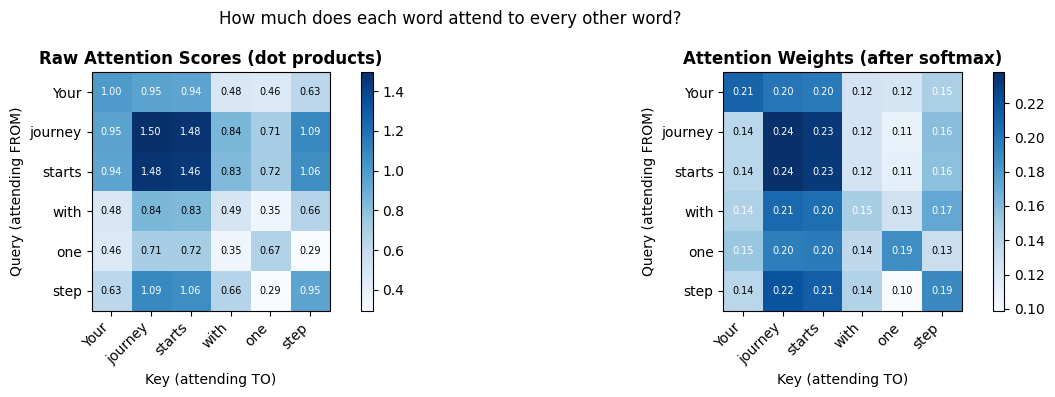

Each row sums to 1.0 (softmax guarantee): [0.9999998807907104, 1.0, 1.0000001192092896, 1.0, 1.0, 1.0]


In [6]:
# Visualise attention weights as a heatmap — the signature transformer plot
import matplotlib.pyplot as plt
import torch

words = ['Your', 'journey', 'starts', 'with', 'one', 'step']
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55],
])

# Compute all attention weights at once (every token attending to every other)
scores = inputs @ inputs.T                      # (6, 6) raw dot products
weights = torch.softmax(scores, dim=-1)         # (6, 6) probabilities per row

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title in zip(
        axes,
        [scores.detach().numpy(), weights.detach().numpy()],
        ['Raw Attention Scores (dot products)', 'Attention Weights (after softmax)']):
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.set_xlabel('Key (attending TO)');  ax.set_ylabel('Query (attending FROM)')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for r in range(len(words)):
        for c in range(len(words)):
            ax.text(c, r, f'{data[r,c]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if data[r,c] > data.max()*0.6 else 'black')

plt.suptitle('How much does each word attend to every other word?', fontsize=12)
plt.tight_layout()
plt.show()

print('Each row sums to 1.0 (softmax guarantee):', weights.sum(dim=-1).tolist())


### What Is the Context Vector?

The context vector is the result of summing all the input vectors, but each vector is scaled by how important it is relative to the query (as indicated by the attention weights). 

This gives the model a concise, weighted summary of the input sequence that can be passed to the next layer or used to generate predictions.

In essence:
- **Important words** (those with higher attention weights) contribute more to the context vector.
- **Less important words** contribute less, allowing the model to focus on the key elements in the sequence.

The context vector plays a critical role in helping the model understand the relationships between words and how they contribute to the overall meaning of the sequence.


### Efficient Calculation of the Context Vector Using Matrix Multiplication

Instead of using a for loop to calculate the context vector, we can utilize **matrix multiplication**. This approach is not only more concise but also significantly faster, especially for larger datasets.

#### Why Use Matrix Multiplication (`@`)?

1. **Performance**: Matrix multiplication leverages optimized underlying libraries (like BLAS) to perform computations efficiently. This is particularly beneficial when dealing with large matrices or tensors, as it can take advantage of parallel processing capabilities.
   
2. **Readability**: Using matrix operations results in cleaner and more readable code, reducing the complexity of iterating through individual elements.


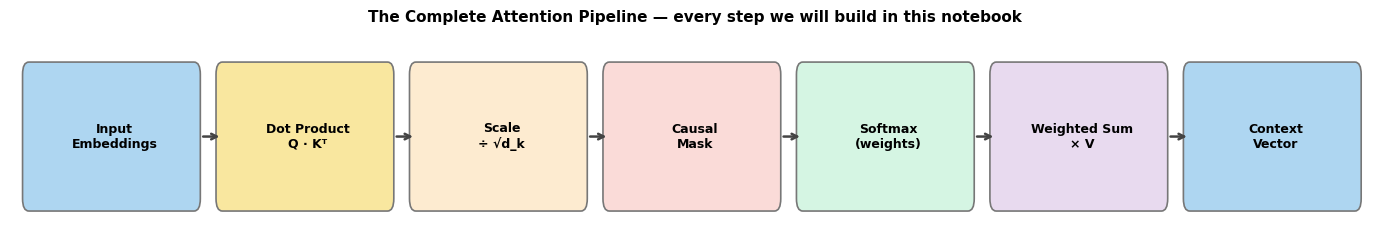

In [7]:
# ── The complete attention pipeline in one picture ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

steps = [
    ('Input\nEmbeddings',      '#AED6F1'),
    ('Dot Product\nQ · Kᵀ',   '#F9E79F'),
    ('Scale\n÷ √d_k',         '#FDEBD0'),
    ('Causal\nMask',           '#FADBD8'),
    ('Softmax\n(weights)',     '#D5F5E3'),
    ('Weighted Sum\n× V',      '#E8DAEF'),
    ('Context\nVector',        '#AED6F1'),
]

fig, ax = plt.subplots(figsize=(14, 2.6))
ax.axis('off')
xs = [i * 1.85 for i in range(len(steps))]

for i, ((label, color), x) in enumerate(zip(steps, xs)):
    rect = mpatches.FancyBboxPatch((x - 0.82, 0.2), 1.58, 0.6,
                                    boxstyle='round,pad=0.06',
                                    facecolor=color, edgecolor='#777', lw=1.2)
    ax.add_patch(rect)
    ax.text(x, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')
    if i < len(steps) - 1:
        ax.annotate('', xy=(xs[i+1] - 0.82, 0.5), xytext=(x + 0.82, 0.5),
                    arrowprops=dict(arrowstyle='->', color='#444', lw=1.8))

ax.set_xlim(-1, xs[-1] + 1)
ax.set_ylim(0, 1)
ax.set_title('The Complete Attention Pipeline — every step we will build in this notebook',
             fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()


In [8]:
import time

# Set a seed for reproducibility
torch.manual_seed(0)

# Generate a larger mock dataset with 1000 input vectors, each of dimension 3
num_vectors = 1000
input_dimension = 3
inputs_mock = torch.rand((num_vectors, input_dimension))

# Simulate attention weights for the dataset, ensuring they sum to 1 for a valid probability distribution
attention_weights = torch.rand(num_vectors)
attention_weights /= attention_weights.sum()  # Normalize to create a probability distribution

# Calculate the context vector using a for loop
start_loop = time.time()  # Start timing the for loop calculation
context_vector_loop = torch.zeros(input_dimension)  # Initialize the context vector

# Iterate through each input vector to compute the weighted sum
for i in range(num_vectors):
    context_vector_loop += attention_weights[i] * inputs_mock[i]  # Accumulate the weighted inputs

end_loop = time.time()  # End timing the for loop
loop_time = end_loop - start_loop  # Calculate the total time taken for the for loop

# Calculate the context vector using matrix multiplication
start_matmul = time.time()  # Start timing the matrix multiplication calculation
context_vector_matmul = attention_weights @ inputs_mock  # Compute the context vector using @ operator
end_matmul = time.time()  # End timing the matrix multiplication
matmul_time = end_matmul - start_matmul  # Calculate the total time taken for matrix multiplication

# Print the resulting context vectors and execution times
print("Context Vector (for loop):", context_vector_loop)
print("Execution Time (for loop): {:.6f} seconds".format(loop_time))

print("Context Vector (matrix multiplication):", context_vector_matmul)
print("Execution Time (matrix multiplication): {:.6f} seconds".format(matmul_time))


Context Vector (for loop): tensor([0.5080, 0.4915, 0.4942])
Execution Time (for loop): 0.015003 seconds
Context Vector (matrix multiplication): tensor([0.5080, 0.4915, 0.4942])
Execution Time (matrix multiplication): 0.000171 seconds


# Adding Learnable Parameters to Attention Mechanism

What we have calculated so far is known as **attention without weights**. While this initial approach helps us understand how attention scores are computed, it lacks the capacity for the model to learn and improve its performance over time.

To enable the model to learn, we need to introduce **learnable parameters** into our attention mechanism. These parameters will be randomly initialized and then adjusted during the training process through optimization algorithms.

By incorporating learnable weights, our model can better capture the relationships between different input vectors and improve its understanding of the underlying patterns in the data. This learning process is essential for the model to generalize well to new inputs and achieve better performance on various tasks.

In the following sections, we will explore how to implement these learnable parameters in our attention mechanism, transforming it into a more robust and effective component of our language model.

## 🗝️ What Are Queries, Keys, and Values?

This is the single most important concept in this notebook. Before writing any code, understand the analogy:

Think of attention as a **smart database lookup**:

| Component | Role | Analogy |
|-----------|------|---------|
| **Query (Q)** | What this token is *asking for* | A search query |
| **Key (K)** | What each token *advertises* about itself | A document index |
| **Value (V)** | The actual *content* to retrieve | The document itself |

The attention score `Q · Kᵀ` measures how well a query matches each key — exactly like a search engine ranking results by relevance. The softmax turns those scores into weights, and the output is a weighted sum of the Values.

**Crucially:** Q, K, V are just three different linear projections of the *same* input. The model learns three separate weight matrices `Wq`, `Wk`, `Wv` that project each token into these three roles.

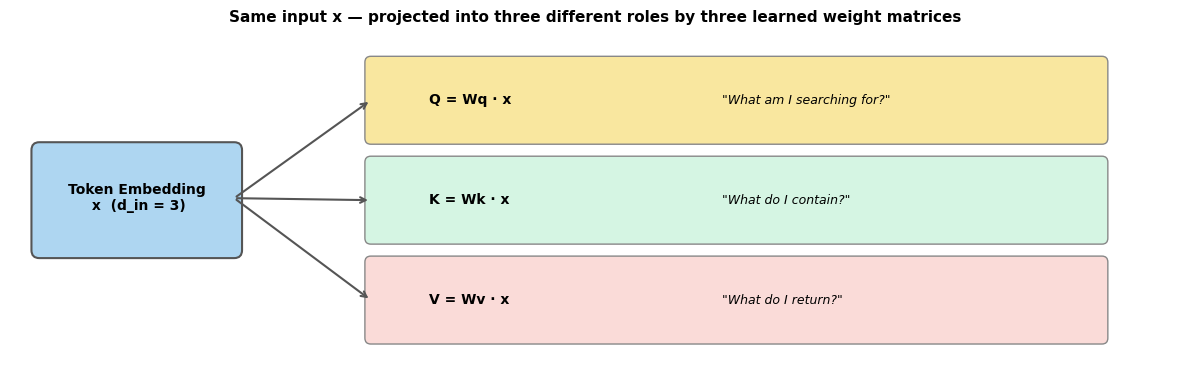

In [9]:
# ── Q, K, V : one input projected three ways ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.axis('off')

# Input box
ax.add_patch(mpatches.FancyBboxPatch((0.3, 1.3), 2.0, 1.0,
             boxstyle='round,pad=0.08', facecolor='#AED6F1', edgecolor='#555', lw=1.5))
ax.text(1.3, 1.82, 'Token Embedding\n x  (d_in = 3)', ha='center', va='center',
        fontsize=10, fontweight='bold')

info = [
    ('Q',  3.8, 2.8, '#F9E79F', 'Wq · x',  '"What am I searching for?"'),
    ('K',  3.8, 1.8, '#D5F5E3', 'Wk · x',  '"What do I contain?"'),
    ('V',  3.8, 0.8, '#FADBD8', 'Wv · x',  '"What do I return?"'),
]
for name, x, y, color, formula, desc in info:
    ax.annotate('', xy=(x - 0.1, y), xytext=(2.3, 1.82),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.1, y - 0.38), 7.5, 0.76,
                 boxstyle='round,pad=0.06', facecolor=color, edgecolor='#888', lw=1))
    ax.text(x + 0.5, y, f'{name} = {formula}', ha='left', va='center',
            fontsize=10, fontweight='bold')
    ax.text(x + 3.5, y, desc, ha='left', va='center', fontsize=9, style='italic')

ax.set_xlim(0, 12)
ax.set_ylim(0.2, 3.5)
ax.set_title('Same input x — projected into three different roles by three learned weight matrices',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# Define input dimensions and output dimensions
d_in = 3  # Input dimension: the size of each word vector (3 features)
d_out = 2  # Output dimension: the size of the transformed vectors (2 features)

# Initialize learnable parameters for query, key, and value
# These parameters will be optimized during training to improve the model's performance.
w_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=True)  # Weights for transforming input to query vectors
w_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=True)    # Weights for transforming input to key vectors
w_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=True)  # Weights for transforming input to value vectors

# Display the initialized parameters
print("Initialized Query Weights (w_query):\n", w_query)
print("Initialized Key Weights (w_key):\n", w_key)
print("Initialized Value Weights (w_value):\n", w_value)

Initialized Query Weights (w_query):
 Parameter containing:
tensor([[0.7487, 0.3674],
        [0.8775, 0.0630],
        [0.9279, 0.7798]], requires_grad=True)
Initialized Key Weights (w_key):
 Parameter containing:
tensor([[0.1333, 0.0922],
        [0.8910, 0.9933],
        [0.5436, 0.3046]], requires_grad=True)
Initialized Value Weights (w_value):
 Parameter containing:
tensor([[0.7847, 0.7256],
        [0.4376, 0.9003],
        [0.8241, 0.6247]], requires_grad=True)


In [11]:
# now let reimplemt what we did previously , but now with the weights we just initialized

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your     (x¹)
     [0.55, 0.87, 0.66],  # journey  (x²)
     [0.57, 0.85, 0.64],  # starts   (x³)
     [0.22, 0.58, 0.33],  # with     (x⁴)
     [0.77, 0.25, 0.10],  # one      (x⁵)
     [0.05, 0.80, 0.55]]  # step     (x⁶)
)

# 1. Transform the inputs into query, key, and value vectors using the initialized weights
queries = inputs @ w_query  # Shape: (6, 2) after transformation to query vectors
keys = inputs @ w_key      # Shape: (6, 2) after transformation to key vectors
values = inputs @ w_value   # Shape: (6, 2) after transformation to value vectors

# 2. Calculate attention scores using the dot product of queries and keys
d_k = keys.shape[-1]  # dimension used for scaling
attention_scores = queries @ keys.T / (d_k ** 0.5)  # scale to prevent softmax saturation

# 3. Calculate attention weights using softmax
attention_weights = torch.nn.functional.softmax(attention_scores, dim=1)  # Shape: (6, 6)

# 4. Calculate the context vector by multiplying attention weights with the value vectors
context_vector = attention_weights @ values  # Shape: (6, 2)

# Display results
print("Queries:\n", queries)
print("\nKeys:\n", keys)
print("\nValues:\n", values)
print("\nAttention Scores:\n", attention_scores)
print("\nAttention Weights:\n", attention_weights)
print("\nContext Vector:\n", context_vector)


Queries:
 tensor([[1.2794, 0.8614],
        [1.7877, 0.7716],
        [1.7665, 0.7620],
        [0.9799, 0.3747],
        [0.8887, 0.3766],
        [1.2498, 0.4977]], grad_fn=<MmBackward0>)

Keys:
 tensor([[0.6748, 0.4598],
        [1.2073, 1.1159],
        [1.1812, 1.0918],
        [0.7255, 0.6969],
        [0.3797, 0.3498],
        [1.0185, 0.9668]], grad_fn=<MmBackward0>)

Values:
 tensor([[1.1365, 1.0030],
        [1.3562, 1.5946],
        [1.3467, 1.5786],
        [0.6984, 0.8879],
        [0.7960, 0.8462],
        [0.8426, 1.1001]], grad_fn=<MmBackward0>)

Attention Scores:
 tensor([[0.8905, 1.7719, 1.7337, 1.0809, 0.5566, 1.5103],
        [1.1038, 2.1349, 2.0888, 1.2973, 0.6708, 1.8149],
        [1.0906, 2.1093, 2.0638, 1.2818, 0.6628, 1.7931],
        [0.5894, 1.1322, 1.1077, 0.6873, 0.3558, 0.9618],
        [0.5465, 1.0558, 1.0331, 0.6415, 0.3318, 0.8975],
        [0.7581, 1.4596, 1.4281, 0.8864, 0.4587, 1.2403]],
       grad_fn=<DivBackward0>)

Attention Weights:
 tensor([[0.

## ⚖️ Why Do We Scale by 1/√d_k?

Look at the `AttentionV1` forward pass — the attention score is divided by `keys.shape[-1] ** 0.5`.

**The problem without scaling:**
As the embedding dimension `d_k` grows (GPT-2 uses 64 per head), dot products grow proportionally with `d_k`. Large scores push the softmax into its **saturation region** — outputs become near-zero or near-one, gradients vanish, and the model stops learning.

**The fix:**
Dividing by `√d_k` keeps the variance of the dot product constant regardless of dimension, so softmax always receives well-scaled inputs.

The plot below makes this concrete — watch what happens at `d_k = 512` without scaling:

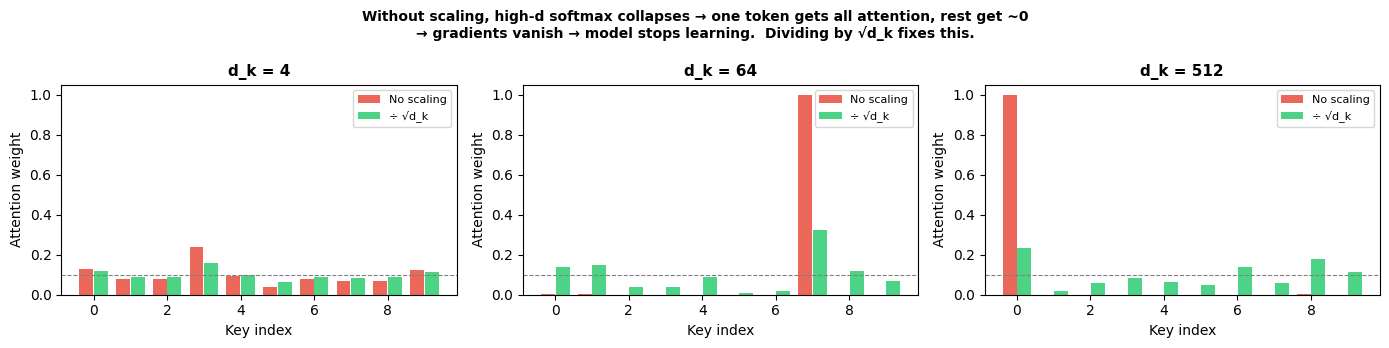

In [12]:
import torch, matplotlib.pyplot as plt

torch.manual_seed(42)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, d in zip(axes, [4, 64, 512]):
    q      = torch.randn(d)
    keys   = torch.randn(10, d)
    raw    = keys @ q
    scaled = raw / (d ** 0.5)
    w_raw    = torch.softmax(raw,    dim=0).numpy()
    w_scaled = torch.softmax(scaled, dim=0).numpy()
    x = range(10)
    ax.bar([i - 0.2 for i in x], w_raw,    0.38, label='No scaling', color='#E74C3C', alpha=0.85)
    ax.bar([i + 0.2 for i in x], w_scaled, 0.38, label='÷ √d_k',    color='#2ECC71', alpha=0.85)
    ax.axhline(0.1, color='grey', linestyle='--', lw=0.8)
    ax.set_title(f'd_k = {d}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Key index'); ax.set_ylabel('Attention weight')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)

plt.suptitle(
    'Without scaling, high-d softmax collapses → one token gets all attention, rest get ~0\n'
    '→ gradients vanish → model stops learning.  Dividing by √d_k fixes this.',
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Define the Attention class
class AttentionV1(torch.nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        # Initialize learnable parameters for query, key, and value transformations
        # These parameters will be optimized during training.
        self.w_query = torch.nn.Parameter(torch.rand(d_in, d_out))  # (3,2): Transforms input features to query vectors
        self.w_key = torch.nn.Parameter(torch.rand(d_in, d_out))    # (3,2): Transforms input features to key vectors
        self.w_value = torch.nn.Parameter(torch.rand(d_in, d_out))  # (3,2): Transforms input features to value vectors

    def forward(self, x):
        # Calculate keys, queries, and values by multiplying the input tensor x with the corresponding weight matrices
        keys = x @ self.w_key   # (6, 3) * (3, 2) -> (6, 2)
        query = x @ self.w_query # (6, 3) * (3, 2) -> (6, 2)
        value = x @ self.w_value # (6, 3) * (3, 2) -> (6, 2)

        # Compute the attention scores by taking the dot product of the query with the transpose of the keys
        # This results in a score matrix of shape (6, 6), indicating how much attention each input should pay to every other input
        attention_score = query @ keys.T # (6, 2) * (2, 6) -> (6, 6)

        # Apply the softmax function to the attention scores to obtain attention weights
        # This normalizes the scores to a probability distribution, allowing us to interpret the scores as weights
        attention_weight = F.softmax(attention_score / (keys.shape[-1] ** 0.5), dim=-1)

        # Calculate the context vector by multiplying the attention weights with the values
        # The context vector is a weighted sum of the values, providing a summary of the input based on the attention mechanism
        context_vector = attention_weight @ value # (6, 6) * (6, 2) -> (6, 2)

        return context_vector


In [14]:
torch.manual_seed(123)
self_attention = AttentionV1(d_in, d_out)
print(self_attention(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


# An Even More Efficient Implementation: Using `nn.Linear`

In our previous implementation of the attention mechanism, we used manually defined weight matrices for queries, keys, and values. While this method works, it can be improved for both efficiency and clarity by utilizing PyTorch's built-in `nn.Linear` class.

### Benefits of Using `nn.Linear`

1. **Simplified Code**: 
   - Using `nn.Linear` allows us to define layers more succinctly. We can create weight matrices and biases automatically without having to manually initialize and manage them.

2. **Automatic Parameter Management**: 
   - `nn.Linear` automatically handles the creation of learnable parameters (weights and biases) and their gradients during backpropagation. This reduces the likelihood of errors and simplifies the code.

3. **Optimized Computation**:
   - The `nn.Linear` layer is optimized for performance, leveraging lower-level operations that are highly efficient. This can lead to faster computations, especially when working with large datasets or deep architectures.

4. **Consistency with PyTorch's Framework**:
   - Integrating `nn.Linear` into our model ensures compatibility with other PyTorch components, such as `nn.Sequential`, making it easier to build and expand models.

### Example Implementation

Using `nn.Linear`, we can redefine the previous attention mechanism as follows:



In [15]:
# more effienct version of the attention class

class AttentionV2(nn.Module):
    def __init__(self, d_in, d_out, bias=False):
        super().__init__()
        # Initialize linear layers for query, key, and value transformations
        # d_in: input feature dimension
        # d_out: output feature dimension
        # bias: whether to include bias in the linear layers
        self.W_query = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for queries
        self.W_key = nn.Linear(d_in, d_out, bias=bias)    # Linear layer for keys
        self.W_value = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for values

    def forward(self, x):
        # Apply linear transformations to the input x to obtain keys, values, and queries
        keys = self.W_key(x)       # Transform input into key representations
        values = self.W_value(x)   # Transform input into value representations
        query = self.W_query(x)    # Transform input into query representations

        # Calculate the attention scores by taking the dot product of queries and keys
        attention_score = query @ keys.T  # (batch_size, d_out) @ (batch_size, d_out).T -> (batch_size, batch_size)

        # Scale the attention scores to prevent large values leading to extreme softmax outputs
        attention_weight = torch.softmax(attention_score / (keys.shape[-1] ** 0.5), dim=-1)  # Scale and normalize

        # Compute the context vector as a weighted sum of values using the attention weights
        con_vector = attention_weight @ values  # (batch_size, batch_size) @ (batch_size, d_out) -> (batch_size, d_out)

        return con_vector  # Return the context vector


In [16]:
torch.manual_seed(123)
self_attention = AttentionV2(d_in, d_out)
print(self_attention(inputs))

tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


# Why the Output is Different

1. **Weight Initialization**:
   - **AttentionV1**: Uses fixed weights initialized with `torch.rand`, which are not learnable.
   - **AttentionV2**: Utilizes `nn.Linear`, providing weights initialized from a normal distribution and making them learnable.

2. **Learnability of Parameters**:
   - **AttentionV1**: Parameters are static, leading to no adaptation based on input.
   - **AttentionV2**: Learnable parameters are updated during training, allowing for dynamic adjustment.

3. **Computational Efficiency**:
   - **AttentionV1**: Implements manual matrix multiplication, which may be less efficient.
   - **AttentionV2**: Leverages `nn.Linear`, optimized for performance.

4. **Output Consistency**:
   - Due to the differences in weight initialization, learnability, and computational methods, the outputs of the two classes will differ, even with identical input data.


## 🚨 The Problem — Why Regular Attention Breaks Text Generation

Imagine training a model to complete:

> *`"The cat sat on the [MASK]"`*

With standard attention, when computing the output for `[MASK]`, the model can **attend to its own answer** during training — it sees the full sequence including the token it is supposed to predict. That is cheating.

Worse: at inference time there *is* no future token to look at yet, so the model has learned a shortcut that completely breaks down.

This is called **information leakage** — future tokens bleeding into past positions.

**The fix is simple:** block every position from attending to any position that comes *after* it. Token 1 sees only itself. Token 2 sees tokens 1–2. Token 3 sees tokens 1–3. And so on.

That is all causal (masked) attention does — applied via an upper-triangular mask before softmax.

# Understanding Causal Attention

Causal attention, also known as masked attention, is a mechanism used in sequence models, particularly in transformers, to ensure that the predictions for a given token depend only on the previous tokens in the sequence. This is essential in tasks like language modeling and autoregressive generation, where the model should not have access to future information when making predictions.

### Key Concepts of Causal Attention:

1. **Sequential Dependency**:
   - Causal attention preserves the temporal order of the data, allowing the model to consider only the past and present tokens when generating a prediction for the next token. This prevents any "leakage" of future information into the model's predictions.

2. **Masking Future Tokens**:
   - In practice, this is implemented by applying a mask to the attention scores, where positions corresponding to future tokens are set to a very large negative value (e.g., `-inf`) before applying the softmax function. This ensures that the softmax outputs for these positions become zero, effectively ignoring them in the attention computation.

3. **Applications**:
   - Causal attention is commonly used in autoregressive models like GPT (Generative Pre-trained Transformer) for text generation, where the model predicts the next word based only on the words that have come before it.

### Illustration:
- Given a sequence of tokens `[A, B, C, D]`, during the prediction for token `D`, the model can only attend to tokens `A`, `B`, and `C`, but not to `D` or any subsequent tokens.

By utilizing causal attention, models can effectively learn to generate sequences in a coherent and contextually appropriate manner, while maintaining the integrity of the sequential data.


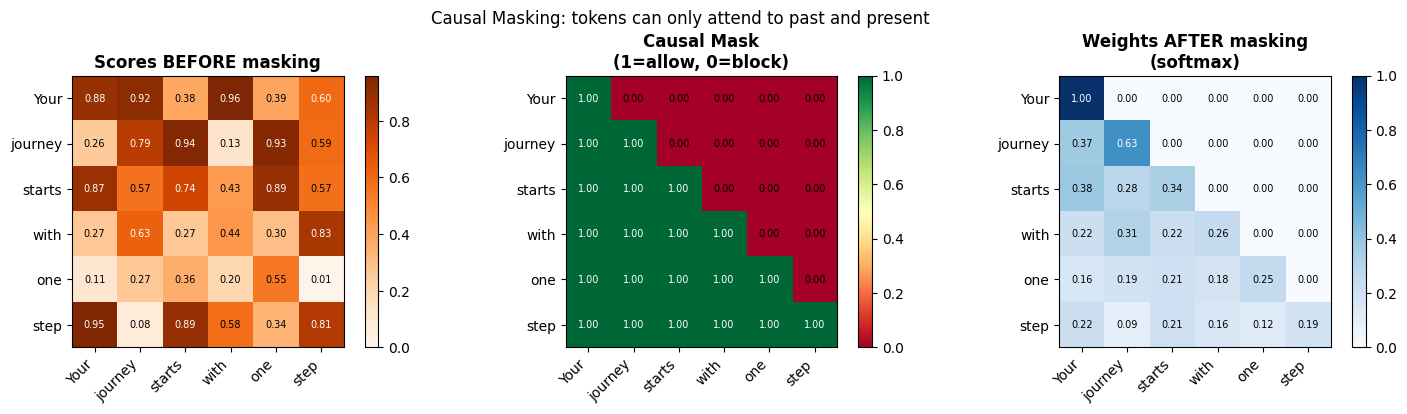

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

seq_len = 6
words   = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Simulated raw attention scores (before masking)
torch.manual_seed(42)
scores = torch.rand(seq_len, seq_len)
mask   = torch.tril(torch.ones(seq_len, seq_len))           # lower-triangular = allowed
masked = scores.masked_fill(mask == 0, float('-inf'))       # upper = -inf
weights_masked = torch.softmax(masked, dim=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (scores.numpy(),          'Scores BEFORE masking',  'Oranges'),
    (mask.numpy(),            'Causal Mask\n(1=allow, 0=block)', 'RdYlGn'),
    (weights_masked.numpy(),  'Weights AFTER masking\n(softmax)', 'Blues'),
]
for ax, (data, title, cmap) in zip(axes, datasets):
    im = ax.imshow(data, cmap=cmap, vmin=0)
    ax.set_xticks(range(seq_len)); ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_yticks(range(seq_len)); ax.set_yticklabels(words)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for r in range(seq_len):
        for c in range(seq_len):
            val = data[r, c]
            txt = '−∞' if np.isinf(-val) else f'{val:.2f}'
            ax.text(c, r, txt, ha='center', va='center', fontsize=7,
                    color='white' if val > 0.6 else 'black')

plt.suptitle('Causal Masking: tokens can only attend to past and present', fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# so basically we apply a mask to the self attention layer to prevent information leakage 
# whuch cruisal for text generation application 
# here a basic example for understanding the mask

# Example parameters
seq_length = 4
batch_size = 2

# Create an example attention score matrix
attention_scores = torch.rand(batch_size, seq_length, seq_length)

# Create a causal mask (lower triangular matrix)
causal_mask = torch.tril(torch.ones(seq_length, seq_length)).to(attention_scores.device)  # Shape: (seq_length, seq_length)

# Apply the mask to attention scores
masked_attention_scores = attention_scores.masked_fill(causal_mask == 0, float('-inf'))

# Calculate attention weights
attention_weights = torch.softmax(masked_attention_scores, dim=-1)

print("Masked Attention Scores:\n", masked_attention_scores)
print("Attention Weights:\n", attention_weights)


Masked Attention Scores:
 tensor([[[0.5779,   -inf,   -inf,   -inf],
         [0.6343, 0.3644,   -inf,   -inf],
         [0.7890, 0.2814, 0.7886,   -inf],
         [0.7539, 0.1952, 0.0050, 0.3068]],

        [[0.1165,   -inf,   -inf,   -inf],
         [0.6581, 0.4913,   -inf,   -inf],
         [0.5315, 0.1587, 0.6542,   -inf],
         [0.6532, 0.3958, 0.9147, 0.2036]]])
Attention Weights:
 tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.5671, 0.4329, 0.0000, 0.0000],
         [0.3844, 0.2314, 0.3842, 0.0000],
         [0.3725, 0.2131, 0.1762, 0.2382]],

        [[1.0000, 0.0000, 0.0000, 0.0000],
         [0.5416, 0.4584, 0.0000, 0.0000],
         [0.3547, 0.2443, 0.4010, 0.0000],
         [0.2696, 0.2084, 0.3501, 0.1720]]])


Before we implement the full `CausalAttention` class, we need to cover one more concept: 
## Dropout: A Regularization Method in Neural Networks

### What is Dropout?

Dropout is a popular regularization technique used in neural networks to prevent overfitting during training. The fundamental idea behind dropout is to randomly "drop out" (set to zero) a proportion of the neurons in a layer during each training iteration. This forces the network to learn more robust features that are not reliant on any single neuron.

### How Does Dropout Work?

1. **Random Neuron Deactivation**: During training, for each forward pass, a specified fraction of neurons is randomly chosen to be set to zero. This effectively removes those neurons from the network for that iteration.

2. **Dropout Rate**: The proportion of neurons to drop out is controlled by a hyperparameter called the **dropout rate** (commonly set between 0.2 to 0.5). For example, a dropout rate of 0.5 means that 50% of the neurons will be randomly deactivated during a forward pass.

3. **Training vs. Inference**:
   - **During Training**: Dropout is applied, and the network learns to function without relying on specific neurons. This promotes the learning of redundant representations, which increases robustness.
   - **During Inference**: All neurons are used, but the output of each neuron is scaled by the dropout rate. This scaling ensures that the expected output remains consistent during training and inference.

### Benefits of Dropout

- **Prevents Overfitting**: By forcing the network to learn from a different subset of neurons each time, dropout helps mitigate the risk of overfitting to the training data.
- **Improves Generalization**: The regularization effect of dropout typically leads to better performance on unseen data, as the model becomes less dependent on any specific feature or neuron.
- **Increases Robustness**: Dropout encourages the network to learn distributed representations, making it more resilient to variations in input data.


In [ ]:
import torch
import torch.nn as nn 

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout_rate=0.1, bias=False):
        super().__init__()
        # Initialize linear layers for query, key, and value transformations
        # d_in: input feature dimension
        # d_out: output feature dimension
        # bias: whether to include bias in the linear layers
        self.W_query = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for queries
        self.W_key = nn.Linear(d_in, d_out, bias=bias)    # Linear layer for keys
        self.W_value = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for values
        self.dropout = nn.Dropout(dropout_rate) 
        # Create an upper triangular mask to prevent information leakage
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        # Apply linear transformations to the input x to obtain keys, values, and queries
        batch_size, num_token, d_in = x.shape 
        keys = self.W_key(x)
        query = self.W_query(x)
        values = self.W_value(x)

        # Calculate attention scores
        attention_scores = query @ keys.transpose(1, 2)

        # Apply the causal mask
        attention_scores = attention_scores.masked_fill(self.mask[:num_token, :num_token] == 1, -torch.inf)

        # Calculate attention weights
        attention_weight = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)
        attention_weight = self.dropout(attention_weight)
        
        # Compute the context vector
        context_vector = attention_weight @ values
        return context_vector


In [20]:
# Example usage
d_in = 3   # Input feature dimension
d_out = 2  # Output feature dimension
context_length = 6  # Number of tokens in the context
dropout_rate = 0.1  # Dropout rate

# Create an instance of the CausalAttention class
causal_attention = CausalAttention(d_in, d_out, context_length, dropout_rate)

# Sample input (batch_size, num_tokens, feature_dimension)
x = torch.rand(2, context_length, d_in)  # A batch of 2 sequences with 6 tokens each and 3 features

# Forward pass
context_vector = causal_attention(x)
print(context_vector.shape)  # Output shape should be (batch_size, num_tokens, d_out)


torch.Size([2, 6, 2])


## Understanding PyTorch Buffers

In PyTorch, a **buffer** is a special type of attribute that is registered to a `Module`, similar to a parameter. Buffers are not considered model parameters and do not require gradients, but they are still part of the model's state. This means they will be moved to the correct device (CPU or GPU) along with the model when the model is moved, making them essential for maintaining consistency in model behavior across different devices.

### Why Use Buffers?

Buffers are typically used for storing constant tensors that you want to be part of the model's state but should not be updated during training. This can include masks, statistics for normalization, or other fixed tensors that are necessary for the model's forward pass.

### Example: Causal Mask

In the `CausalAttention` class, we use `register_buffer` to create a causal mask:

```python
self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))
```

#### Breakdown of the Code:
- `torch.ones(context_length, context_length)`: Creates a 2D tensor filled with ones of shape `(context_length, context_length)`.
- `torch.triu(..., diagonal=1)`: Converts the tensor into an upper triangular matrix, setting all elements below the main diagonal to zero. This prevents future information from being accessed during the attention calculation, which is crucial for tasks like text generation.
- `self.register_buffer('mask', ...)`: Registers the mask tensor as a buffer named `mask` within the model, ensuring it is accessible during the forward pass without being treated as a trainable parameter.

Using buffers effectively allows you to maintain important constant values within your model while ensuring that the parameters and gradients are handled separately.

## Multi-Head Attention

Multi-head attention is an extension of the attention mechanism that allows the model to focus on different parts of the input sequence simultaneously. Instead of performing a single attention function, multi-head attention runs multiple attention mechanisms (or "heads") in parallel and then concatenates their outputs. This design enhances the model's ability to capture various relationships and features in the data, providing richer representations.

### Key Concepts

1. **Parallel Attention Heads**:
   - Each attention head learns to focus on different aspects of the input sequence. For example, one head might learn to attend to local relationships, while another might focus on global dependencies.
   - By using multiple heads, the model can gather information from different representation subspaces, enabling it to capture complex patterns.

2. **Linear Transformations**:
   - For each head, separate linear transformations are applied to the input to obtain queries, keys, and values. This is done by using distinct learned weight matrices for each head.
   - The transformation helps project the input data into different feature spaces, allowing each head to learn different features.

3. **Attention Calculation**:
   - Each head computes its attention scores and corresponding context vectors independently. The attention mechanism for each head follows the same principles as standard attention, utilizing the dot product of queries and keys to determine how much focus each token should have on the others.

4. **Concatenation and Linear Projection**:
   - After computing the context vectors from each head, the outputs are concatenated and passed through a final linear layer. This step combines the information from all heads into a single unified representation.

### Benefits of Multi-Head Attention

- **Diversity of Attention**: Multi-head attention allows the model to attend to different parts of the input in various ways, making it more robust to complex tasks.
- **Enhanced Representational Power**: By aggregating information from multiple heads, the model can develop a richer understanding of the relationships within the data.
- **Improved Performance**: Multi-head attention has been shown to improve performance in various natural language processing tasks, such as translation, text generation, and sentiment analysis.

### Conclusion

Multi-head attention is a fundamental building block of modern transformer architectures, enabling models to effectively handle complex dependencies in data. By leveraging the strengths of multiple attention mechanisms, it enhances the model's overall capability to learn and generalize from the input data.


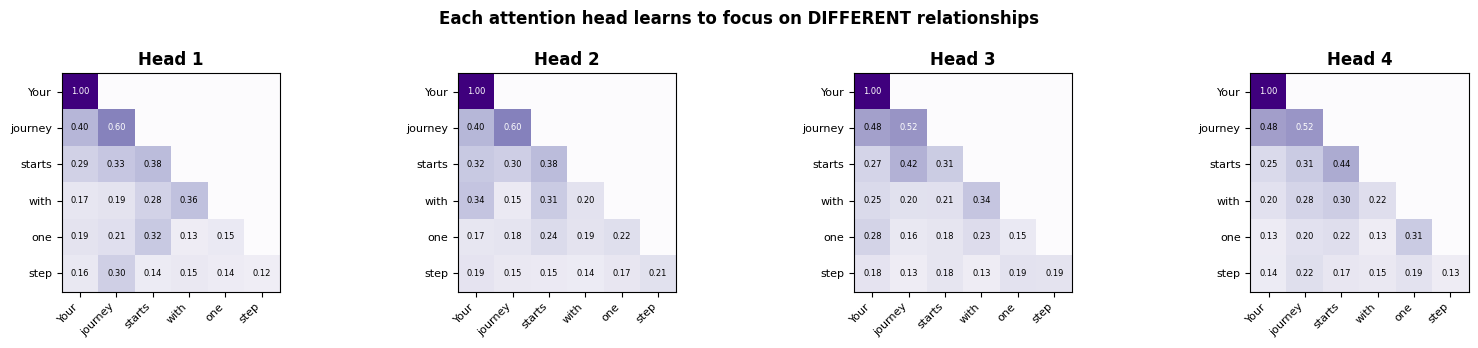

All 4 heads run in PARALLEL then their outputs are concatenated + projected.


In [21]:
# Visualise how multiple heads produce DIFFERENT attention patterns
import matplotlib.pyplot as plt
import torch

words = ['Your', 'journey', 'starts', 'with', 'one', 'step']
n     = len(words)
torch.manual_seed(0)

# Simulate 4 heads with different random projections
n_heads = 4
fig, axes = plt.subplots(1, n_heads, figsize=(16, 3.5))
fig.suptitle('Each attention head learns to focus on DIFFERENT relationships',
             fontsize=12, fontweight='bold')

for h, ax in enumerate(axes):
    torch.manual_seed(h * 7)                          # different seed → different pattern
    scores  = torch.rand(n, n)
    mask    = torch.tril(torch.ones(n, n))
    scores  = scores.masked_fill(mask == 0, float('-inf'))
    weights = torch.softmax(scores, dim=-1)

    im = ax.imshow(weights.numpy(), cmap='Purples', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(words, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(words, fontsize=8)
    ax.set_title(f'Head {h+1}', fontweight='bold')
    for r in range(n):
        for c in range(n):
            v = weights[r, c].item()
            if v > 0:
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if v > 0.5 else 'black')

plt.tight_layout()
plt.show()
print('All 4 heads run in PARALLEL then their outputs are concatenated + projected.')


## 🔍 Shape Walkthrough — What Happens Inside `MultiHeadAttention`

The trickiest part is the tensor reshaping. Here is the exact shape at every step for the example we will run below (`batch=2, seq=10, d_in=64, d_out=128, heads=4`):

```
Input              (2, 10, 64)   ← batch, sequence, embedding

Linear projections:
  Q = x @ Wq  →   (2, 10, 128)
  K = x @ Wk  →   (2, 10, 128)
  V = x @ Wv  →   (2, 10, 128)

Split into 4 heads  (d_head = 128 // 4 = 32):
  Q.view(2, 10, 4, 32).transpose(1,2)  →  (2, 4, 10, 32)
  K and V — same reshape               →  (2, 4, 10, 32)

Attention scores   Q @ Kᵀ:
  (2, 4, 10, 32) @ (2, 4, 32, 10)     →  (2, 4, 10, 10)
  scale + causal mask + softmax        →  (2, 4, 10, 10)

Weighted sum       weights @ V:
  (2, 4, 10, 10) @ (2, 4, 10, 32)     →  (2, 4, 10, 32)

Concatenate heads:
  .transpose(1,2) → (2, 10, 4, 32)
  .contiguous().view(2, 10, 128)       →  (2, 10, 128)

Output projection  x @ W_out:
  (2, 10, 128) @ (128, 128)            →  (2, 10, 128)  ← final output
```

Each head sees the **full sequence** but only a **32-dimensional slice** of the embedding. Running 4 heads in parallel is what makes multi-head attention both powerful and efficient.

In [22]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dropout_rate=0.1, bias=False):
        super().__init__()
        # Ensure output dimension is divisible by the number of heads
        assert (d_out % num_heads) == 0
        self.d_out = d_out
        self.num_heads = num_heads 
        self.head_dim = d_out // num_heads
        
        # Initialize linear layers for query, key, and value transformations
        self.W_query = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for queries
        self.W_key = nn.Linear(d_in, d_out, bias=bias)    # Linear layer for keys
        self.W_value = nn.Linear(d_in, d_out, bias=bias)  # Linear layer for values
        
        self.dropout = nn.Dropout(dropout_rate)
        self.proj = nn.Linear(d_out, d_out)
        
        # Create an upper triangular mask to prevent information leakage
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        # Apply linear transformations to the input x to obtain keys, values, and queries
        b, num_tokens, d_in = x.shape  # Input shape: (batch_size, num_tokens, d_in)

        keys = self.W_key(x)  # Shape: (batch_size, num_tokens, d_out)
        values = self.W_value(x)  # Shape: (batch_size, num_tokens, d_out)
        query = self.W_query(x)  # Shape: (batch_size, num_tokens, d_out)

        # Reshape and transpose for multi-head attention
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)  # Shape: (batch_size, num_heads, num_tokens, head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)  # Shape: (batch_size, num_heads, num_tokens, head_dim)
        query = query.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)  # Shape: (batch_size, num_heads, num_tokens, head_dim)

        # Compute attention scores
        attention_score = query @ keys.transpose(2, 3)  # Shape: (batch_size, num_heads, num_tokens, num_tokens)

        # Apply mask to attention scores
        mask_bool = self.mask[:num_tokens, :num_tokens].bool()  # Shape: (num_tokens, num_tokens)
        attention_score.masked_fill_(mask_bool, -torch.inf)  # Shape remains: (batch_size, num_heads, num_tokens, num_tokens)

        # Calculate attention weights
        attention_weight = torch.softmax(attention_score / keys.shape[-1] ** 0.5, dim=-1)  # Shape: (batch_size, num_heads, num_tokens, num_tokens)
        attention_weight = self.dropout(attention_weight)

        # Calculate context vector
        all_con_vec = (attention_weight @ values)  # Shape: (batch_size, num_heads, num_tokens, head_dim)
        all_con_vec = all_con_vec.transpose(1, 2)  # Shape: (batch_size, num_tokens, num_heads, head_dim)
        all_con_vec = all_con_vec.contiguous().view(b, num_tokens, self.d_out)  # Shape: (batch_size, num_tokens, d_out)

        # Project the output
        output = self.proj(all_con_vec)  # Shape: (batch_size, num_tokens, d_out)
        return output


# Testing the MultiheadAttention Class

Finally, let's put the `MultiheadAttention` class to the test by checking the output shape and counting the number of learnable parameters.

We will create a dummy input tensor with a specified batch size and number of tokens. After passing the input through the `MultiheadAttention` layer, we'll verify the shape of the output to ensure it matches the expected dimensions. Additionally, we'll count the total number of learnable parameters in the class to understand its complexity and capacity.

By performing these checks, we can confirm that our implementation is functioning correctly and is ready for further experimentation or integration into a larger model.


In [ ]:
# Define the input dimensions
d_in = 64           # Input feature dimension
d_out = 128         # Output feature dimension
context_length = 10 # Maximum number of tokens in the input sequence
num_heads = 8       # Number of attention heads
dropout_rate = 0.1  # Dropout rate

# Create an instance of the MultiheadAttention class
multihead_attention = MultiheadAttention(d_in,
                                        d_out,
                                        context_length,
                                        num_heads,
                                        dropout_rate
                                        )

# Prepare a dummy input tensor
batch_size = 2                    # Number of sequences in a batch
num_tokens = context_length        # Length of the input sequence (can be less than context_length)
dummy_input = torch.randn(batch_size, num_tokens, d_in)  # Shape: (batch_size, num_tokens, d_in)

# Pass the dummy input through the MultiheadAttention layer
output = multihead_attention(dummy_input)

# Display the shape of the output
print("Output shape:", output.shape)  # Expected shape: (batch_size, num_tokens, d_out)

# Count the number of parameters
num_params = sum(p.numel() for p in multihead_attention.parameters() if p.requires_grad)
print("Number of parameters:", num_params)


Output shape: torch.Size([2, 10, 128])
Number of parameters: 41088


# Summary of the Notebook

In this notebook, we explored the concepts and implementations of various attention mechanisms in deep learning, focusing on self-attention, causal attention, and multi-head attention. Here's a summary of the key points covered:

1. **Attention Mechanism**: We started by understanding the basics of attention mechanisms, which allow models to focus on relevant parts of the input data while processing it. We discussed the significance of attention scores, weights, and context vectors.

2. **Causal Attention**: We introduced causal attention, highlighting its importance in text generation tasks to prevent information leakage from future tokens. This was implemented using masking techniques.

3. **Dropout Regularization**: We covered the concept of dropout as a regularization method to prevent overfitting during training by randomly dropping a fraction of the neurons.

4. **Multi-Head Attention**: We then implemented a multi-head attention class, allowing the model to attend to different parts of the input in parallel, enhancing its ability to capture complex relationships.

5. **Understanding Buffers**: We discussed the use of `register_buffer` for managing non-trainable parameters, such as masks, which are essential for certain operations in attention mechanisms.

6. **Testing the Implementation**: Finally, we tested our multi-head attention implementation by checking the output shape and counting the number of parameters, ensuring the model's functionality and capacity were in line with expectations.

Through these steps, we gained hands-on experience with building attention mechanisms in PyTorch, laying the foundation for more advanced applications in natural language processing and beyond.


In [24]:
# We've reached the end of our LLM attention journey! 🎉

def celebrate_llm():
    print("🎉 Congratulations! You've just built the foundations for a language model! 🌐")
    print("🤖 Time to let your model generate some text. Let's see what it has to say...")
    
    responses = [
        "I may not be sentient, but I'm definitely ready for some coffee! ☕",
        "Did you know? The more you train me, the more puns I can generate! 😄",
        "Why did the LLM cross the road? To generate text on the other side! 🐔",
        "Ready to assist you in your next big project. Let's create some magic! ✨"
    ]
    
    import random
    print(random.choice(responses))

celebrate_llm()


🎉 Congratulations! You've just built the foundations for a language model! 🌐
🤖 Time to let your model generate some text. Let's see what it has to say...
I may not be sentient, but I'm definitely ready for some coffee! ☕


# 🎉 We Did It! 🎉

Congratulations! You've successfully implemented the attention mechanisms and laid a solid foundation for what’s to come. 🚀

But this is just the beginning...

In the **next notebook**, we’ll take a bold step forward and **code GPT from scratch**—building it piece by piece. 🛠️ Get ready to bring your very own GPT model to life and explore the fascinating inner workings of generative transformers!

👋 See you in the next notebook. Stay curious and keep pushing the boundaries of what's possible!
